# 🔁 Notebook 5 — Benchmark Cross-Dataset

**Objectif** : Comparer la capacité de généralisation d'un MLP entre deux datasets NFStream différents.

```
Expérience 1 : Train sur Dataset A → Test sur Dataset B
Expérience 2 : Train sur Dataset B → Test sur Dataset A
```

---
## Structure du notebook

**PARTIE 1 — Préprocessing**
- Import des deux CSV
- Nettoyage identique (colonnes partagées, encodage protocol fixe)
- Alignement des colonnes (intersection garantie)
- Export en CSV

**PARTIE 2 — Entraînement & Benchmark**
- Chargement des CSV préprocessés
- Entraînement + test croisé dans les deux sens
- Comparaison des résultats

---
> Le scaler est **toujours fit uniquement sur le dataset d'entraînement** de chaque expérience, jamais sur le test  pour rester rigoureux scientifiquement.

---
# PARTIE 1 — PRÉPROCESSING

## 📦 Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import io
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

print('✅ Imports OK')

✅ Imports OK


## ⚙️ Configuration

In [ ]:
# ============================================================
#  1. NOMS DES DATASETS (pour l'affichage)
# ============================================================
DATASET_A_NAME = "ID2T_Portscan"
DATASET_B_NAME = "TonIOT_Portscan"

# ============================================================
#  2. COLONNE LABEL — identique pour les deux (même schema NFStream)
# ============================================================
LABEL_COL = "label"

# ============================================================
#  3. LABELS CONSIDERES COMME "NORMAL" (le reste = attaque)
# ============================================================
BENIGN_LABELS = ["Benign", "BENIGN", "benign"]

# ============================================================
#  4. COLONNES A SUPPRIMER - partagees entre A et B
# ============================================================
COLS_TO_DROP_MANUAL = [
    "id", "expiration_id",
    "src_ip", "src_mac", "src_oui",
    "dst_ip", "dst_mac", "dst_oui",
    "bidirectional_first_seen_ms", "bidirectional_last_seen_ms",
    "src2dst_first_seen_ms",       "src2dst_last_seen_ms",
    "dst2src_first_seen_ms",       "dst2src_last_seen_ms",
    "vlan_id", "tunnel_id", "ip_version",
    "src_port", "dst_port",
    "application_name", "application_category_name",
    "application_is_guessed", "application_confidence",
    "requested_server_name", "client_fingerprint",
    "server_fingerprint", "user_agent", "content_type",
]

# ============================================================
#  5. COLONNES NOMINALES A ENCODER EN ONE-HOT
#     Les categories sont detectees automatiquement (union des
#     valeurs presentes dans les deux datasets) - rien a coder en dur
# ============================================================
ONEHOT_COLS = ["protocol"]   # ajoute d'autres colonnes nominales si besoin

# ============================================================
#  6. GESTION NaN / Inf
# ============================================================
NAN_STRATEGY = "median"

# ============================================================
#  7. SUPPRESSION DES FEATURES CORRELEES
# ============================================================
DROP_HIGH_CORR = True
CORR_THRESHOLD = 0.95

# ============================================================
#  8. SAUVEGARDE
# ============================================================
SAVE_DIR = "/content/"

print("✅ Configuration chargée")
print(f"   Dataset A : {DATASET_A_NAME}")
print(f"   Dataset B : {DATASET_B_NAME}")
print(f"   Cols à drop (partagées) : {len(COLS_TO_DROP_MANUAL)}")
print(f"   Colonnes OneHot (catégories auto-détectées) : {ONEHOT_COLS}")

✅ Configuration chargée
   Dataset A : ID2T_Portscan
   Dataset B : TonIOT_Portscan
   Cols à drop (partagées) : 28
   Colonnes OneHot (catégories auto-détectées) : ['protocol']


---
## 1️⃣ Import des deux datasets bruts (avant tout nettoyage)

On charge d'abord les deux CSV bruts, car les catégories OneHot
doivent être détectées à partir de l'union des deux AVANT le nettoyage.

### ▶ Dataset A

In [ ]:
print(f"📂 Upload du Dataset A ({DATASET_A_NAME})")
from google.colab import files
uploaded_a = files.upload()
CSV_A_FILENAME = list(uploaded_a.keys())[0]
df_a_raw = pd.read_csv(io.BytesIO(uploaded_a[CSV_A_FILENAME]), low_memory=False)
df_a_raw.columns = df_a_raw.columns.str.strip()

print(f"\n✅ {CSV_A_FILENAME} : {df_a_raw.shape[0]:,} lignes × {df_a_raw.shape[1]} colonnes")

📂 Upload du Dataset A (ID2T_Portscan)


Saving normal_IoT_2_final_labeled.csv to normal_IoT_2_final_labeled.csv

✅ normal_IoT_2_final_labeled.csv : 19,828 lignes × 87 colonnes


### ▶ Dataset B

In [ ]:
print(f"📂 Upload du Dataset B ({DATASET_B_NAME})")
uploaded_b = files.upload()
CSV_B_FILENAME = list(uploaded_b.keys())[0]
df_b_raw = pd.read_csv(io.BytesIO(uploaded_b[CSV_B_FILENAME]), low_memory=False)
df_b_raw.columns = df_b_raw.columns.str.strip()

print(f"\n✅ {CSV_B_FILENAME} : {df_b_raw.shape[0]:,} lignes × {df_b_raw.shape[1]} colonnes")

📂 Upload du Dataset B (TonIOT_Portscan)


Saving normal_scanning1_labeled.csv to normal_scanning1_labeled.csv

✅ normal_scanning1_labeled.csv : 80,074 lignes × 87 colonnes


---
## 2️⃣ Détection automatique des catégories OneHot (union A ∪ B)

Pour chaque colonne de `ONEHOT_COLS`, on calcule l'**union des valeurs**
présentes dans les deux datasets, puis on fit **un seul encoder partagé**.

In [ ]:
def build_shared_onehot_encoders(df_a_raw, df_b_raw, onehot_cols):
    """
    Construit un OneHotEncoder par colonne nominale, fit sur l'UNION
    des valeurs observées dans les deux datasets. Garantit que les deux
    datasets produisent exactement les mêmes colonnes après encodage.
    """
    encoders = {}
    for col in onehot_cols:
        values_a = df_a_raw[col].astype(str).unique() if col in df_a_raw.columns else np.array([])
        values_b = df_b_raw[col].astype(str).unique() if col in df_b_raw.columns else np.array([])
        all_values = sorted(set(values_a) | set(values_b))

        if not all_values:
            print(f"⚠️  '{col}' introuvable dans les deux datasets — ignorée")
            continue

        encoder = OneHotEncoder(
            categories=[all_values],
            handle_unknown='ignore',
            sparse_output=False,
            dtype=np.float32
        )
        encoder.fit(np.array(all_values).reshape(-1, 1))
        encoders[col] = encoder

        print(f"[OneHot] '{col}' — {len(all_values)} catégorie(s) détectée(s) automatiquement : {all_values}")

    return encoders

onehot_encoders = build_shared_onehot_encoders(df_a_raw, df_b_raw, ONEHOT_COLS)

[OneHot] 'protocol' — 4 catégorie(s) détectée(s) automatiquement : ['1', '17', '2', '6']


---
## 3️⃣ Fonction de nettoyage (identique pour A et B)

In [ ]:
def clean_dataset(df_raw, label_col, benign_labels, cols_to_drop,
                   onehot_cols, onehot_encoders, nan_strategy, dataset_name=""):
    """
    Nettoie un dataset NFStream et retourne un DataFrame avec :
    - les features comportementales
    - une colonne 'label_binary' (0=Normal, 1=Attaque)
    Les colonnes nominales sont encodées avec les encoders PARTAGÉS
    (fittés sur l'union A∪B), jamais re-fittés ici.
    """
    df = df_raw.copy()

    y_binary = np.where(df[label_col].isin(benign_labels), 0, 1)
    n_attack = y_binary.sum()
    print(f"[{dataset_name}] Label binaire : {len(y_binary)-n_attack:,} normal / {n_attack:,} attaque")

    existing_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=existing_drop + [label_col], errors='ignore')

    constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
    df = df.drop(columns=constant_cols)

    # ── OneHot avec les encoders PARTAGÉS (transform uniquement) ──
    for col in onehot_cols:
        if col in df.columns and col in onehot_encoders:
            encoder = onehot_encoders[col]
            arr = encoder.transform(df[[col]].astype(str))
            feature_names = encoder.get_feature_names_out([col])
            ohe_df = pd.DataFrame(arr, columns=feature_names, index=df.index)
            df = df.drop(columns=[col])
            df = pd.concat([df, ohe_df], axis=1)

    # ── Autres colonnes catégorielles restantes (sécurité) ──
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    for c in cat_cols:
        df[c] = df[c].astype('category').cat.codes.astype(np.float32)

    # ── Inf → NaN → stratégie ──
    num_cols = df.columns.tolist()
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    n_nan = df[num_cols].isnull().sum().sum()
    if n_nan > 0:
        if nan_strategy == "median":
            df[num_cols] = df[num_cols].fillna(df[num_cols].median())
        elif nan_strategy == "mean":
            df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
        elif nan_strategy == "zero":
            df[num_cols] = df[num_cols].fillna(0)

    df["label_binary"] = y_binary

    print(f"[{dataset_name}] Nettoyage terminé : {df.shape[0]:,} lignes × {df.shape[1]-1} features")
    return df

print("✅ Fonction clean_dataset() définie")

✅ Fonction clean_dataset() définie


---
## 4️⃣ Application du nettoyage aux deux datasets

In [ ]:
df_a_clean = clean_dataset(
    df_a_raw, LABEL_COL, BENIGN_LABELS, COLS_TO_DROP_MANUAL,
    ONEHOT_COLS, onehot_encoders, NAN_STRATEGY, dataset_name=DATASET_A_NAME
)

[ID2T_Portscan] Label binaire : 12,496 normal / 7,332 attaque
[ID2T_Portscan] Nettoyage terminé : 19,828 lignes × 58 features


In [ ]:
df_b_clean = clean_dataset(
    df_b_raw, LABEL_COL, BENIGN_LABELS, COLS_TO_DROP_MANUAL,
    ONEHOT_COLS, onehot_encoders, NAN_STRATEGY, dataset_name=DATASET_B_NAME
)

[TonIOT_Portscan] Label binaire : 5,374 normal / 74,700 attaque
[TonIOT_Portscan] Nettoyage terminé : 80,074 lignes × 58 features


---
## 5️⃣ Alignement des colonnes (intersection garantie)

Même avec une logique identique, des colonnes peuvent diverger légèrement
entre deux datasets (ex: une colonne constante dans A mais pas dans B).
On force l'intersection pour garantir un alignement parfait.

In [ ]:
cols_a = set(df_a_clean.columns) - {"label_binary"}
cols_b = set(df_b_clean.columns) - {"label_binary"}

common_cols = sorted(cols_a & cols_b)
only_in_a   = sorted(cols_a - cols_b)
only_in_b   = sorted(cols_b - cols_a)

if only_in_a:
    print(f"⚠️  Colonnes uniquement dans A (retirées) : {only_in_a}")
if only_in_b:
    print(f"⚠️  Colonnes uniquement dans B (retirées) : {only_in_b}")
if not only_in_a and not only_in_b:
    print("✅ Toutes les colonnes correspondent déjà parfaitement")

feature_cols = common_cols

df_a_clean = df_a_clean[feature_cols + ["label_binary"]]
df_b_clean = df_b_clean[feature_cols + ["label_binary"]]

print(f"\n✅ {len(feature_cols)} features communes alignées")

✅ Toutes les colonnes correspondent déjà parfaitement

✅ 58 features communes alignées


---
## 6️⃣ Suppression des features très corrélées
*Calculée sur Dataset A (référence), appliquée aux deux pour rester alignés*

In [ ]:
if DROP_HIGH_CORR:
    corr_matrix = df_a_clean[feature_cols].corr().abs()
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    cols_to_drop_corr = [
        col for col in upper_tri.columns
        if any(upper_tri[col] >= CORR_THRESHOLD)
    ]

    if cols_to_drop_corr:
        print(f"⚠️  {len(cols_to_drop_corr)} feature(s) supprimée(s) (référence: {DATASET_A_NAME}) :")
        for col in cols_to_drop_corr:
            print(f"   - '{col}'")
        feature_cols = [c for c in feature_cols if c not in cols_to_drop_corr]
        df_a_clean = df_a_clean[feature_cols + ["label_binary"]]
        df_b_clean = df_b_clean[feature_cols + ["label_binary"]]
    else:
        print(f"✅ Aucune feature avec |r| >= {CORR_THRESHOLD}")
else:
    print("⏭️  Suppression par corrélation désactivée")

print(f"\n✅ Features finales : {len(feature_cols)}")

⚠️  24 feature(s) supprimée(s) (référence: ID2T_Portscan) :
   - 'bidirectional_min_piat_ms'
   - 'bidirectional_packets'
   - 'bidirectional_psh_packets'
   - 'bidirectional_stddev_ps'
   - 'dst2src_ack_packets'
   - 'dst2src_duration_ms'
   - 'dst2src_fin_packets'
   - 'dst2src_packets'
   - 'dst2src_stddev_ps'
   - 'src2dst_ack_packets'
   - 'src2dst_bytes'
   - 'src2dst_duration_ms'
   - 'src2dst_ece_packets'
   - 'src2dst_fin_packets'
   - 'src2dst_max_piat_ms'
   - 'src2dst_max_ps'
   - 'src2dst_mean_piat_ms'
   - 'src2dst_min_piat_ms'
   - 'src2dst_min_ps'
   - 'src2dst_packets'
   - 'src2dst_psh_packets'
   - 'src2dst_stddev_piat_ms'
   - 'src2dst_stddev_ps'
   - 'src2dst_syn_packets'

✅ Features finales : 34


---
## 7️⃣ Export des CSV préprocessés

In [ ]:
path_a = f"{SAVE_DIR}{DATASET_A_NAME}_clean.csv"
path_b = f"{SAVE_DIR}{DATASET_B_NAME}_clean.csv"

df_a_clean.to_csv(path_a, index=False)
df_b_clean.to_csv(path_b, index=False)

print(f"✅ Exporté : {path_a}  ({df_a_clean.shape[0]:,} lignes)")
print(f"✅ Exporté : {path_b}  ({df_b_clean.shape[0]:,} lignes)")

files.download(path_a)
files.download(path_b)

✅ Exporté : /content/ID2T_Portscan_clean.csv  (19,828 lignes)
✅ Exporté : /content/TonIOT_Portscan_clean.csv  (80,074 lignes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 8️⃣ Export terminé — passe à la Partie 2 ci-dessous

## 📦 Imports

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)

print('✅ Imports OK')

✅ Imports OK


## ⚙️ Configuration du modèle
*Source : MLP4NIDS (Rosay et al. 2020) + Birch+MLP (arXiv:2208.09711)*

In [ ]:
HIDDEN_LAYERS        = (256, 256)
ACTIVATION            = "relu"
SOLVER                = "adam"
LEARNING_RATE_INIT    = 0.0001
MAX_ITER              = 200
EARLY_STOPPING        = True
N_ITER_NO_CHANGE      = 20
VALIDATION_FRACTION   = 0.2
RANDOM_STATE          = 35

print("✅ Configuration modèle chargée")

✅ Configuration modèle chargée


---
## 7️⃣ Chargement des datasets préprocessés

*(Si tu es dans la même session Colab, les variables df_a_clean / df_b_clean
sont déjà en mémoire — sinon réimporte les CSV exportés à l'étape 6.)*

In [ ]:
import pandas as pd

DATASET_A_NAME = "ID2T_Portscan"
DATASET_B_NAME = "TonIOT_Portscan"
SAVE_DIR       = "/content/"

PATH_A = f"{SAVE_DIR}{DATASET_A_NAME}_clean.csv"
PATH_B = f"{SAVE_DIR}{DATASET_B_NAME}_clean.csv"

df_a_clean = pd.read_csv(PATH_A)
df_b_clean = pd.read_csv(PATH_B)

feature_cols = [c for c in df_a_clean.columns if c != "label_binary"]

print(f"✅ {DATASET_A_NAME} : {df_a_clean.shape[0]:,} lignes  ({PATH_A})")
print(f"✅ {DATASET_B_NAME} : {df_b_clean.shape[0]:,} lignes  ({PATH_B})")
print(f"   Features : {len(feature_cols)}")

✅ ID2T_Portscan : 19,828 lignes  (/content/ID2T_Portscan_clean.csv)
✅ TonIOT_Portscan : 80,074 lignes  (/content/TonIOT_Portscan_clean.csv)
   Features : 34


---
## 8️⃣ Fonction d'expérimentation

In [ ]:
def run_experiment(train_df, test_df, train_name, test_name, feature_cols):
    """
    Entraîne un MLP sur train_df et l'évalue sur test_df.
    Le scaler est fit UNIQUEMENT sur train_df (jamais sur le test).
    """
    print("=" * 60)
    print(f"  EXPERIENCE : Train sur {train_name} -> Test sur {test_name}")
    print("=" * 60)

    X_train = train_df[feature_cols].values
    y_train = train_df["label_binary"].values
    X_test  = test_df[feature_cols].values
    y_test  = test_df["label_binary"].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes  = HIDDEN_LAYERS,
        activation          = ACTIVATION,
        solver              = SOLVER,
        learning_rate_init  = LEARNING_RATE_INIT,
        max_iter            = MAX_ITER,
        early_stopping      = EARLY_STOPPING,
        n_iter_no_change    = N_ITER_NO_CHANGE,
        validation_fraction = VALIDATION_FRACTION,
        random_state        = RANDOM_STATE,
    )

    print(f"\n🚀 Entraînement sur {train_name} ({len(X_train):,} flux)...")
    mlp.fit(X_train_scaled, y_train)
    print(f"   Epochs réalisées : {len(mlp.loss_curve_)} / {MAX_ITER}")

    y_pred = mlp.predict(X_test_scaled)

    print(f"\n📊 Évaluation sur {test_name} ({len(X_test):,} flux)\n")
    report_str = classification_report(
        y_test, y_pred, target_names=["Normal", "Attaque"], zero_division=0
    )
    print(report_str)

    report_dict = classification_report(
        y_test, y_pred, target_names=["Normal", "Attaque"],
        output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    return {
        "train_name": train_name,
        "test_name" : test_name,
        "model"     : mlp,
        "scaler"    : scaler,
        "report"    : report_dict,
        "cm"        : cm,
        "n_train"   : len(X_train),
        "n_test"    : len(X_test),
    }

print("✅ Fonction run_experiment() définie")

✅ Fonction run_experiment() définie


---
## 9️⃣ Expérience 1 — Train sur A, Test sur B

In [ ]:
exp_A_to_B = run_experiment(df_a_clean, df_b_clean, DATASET_A_NAME, DATASET_B_NAME, feature_cols)

  EXPERIENCE : Train sur ID2T_Portscan -> Test sur TonIOT_Portscan

🚀 Entraînement sur ID2T_Portscan (19,828 flux)...
   Epochs réalisées : 24 / 200

📊 Évaluation sur TonIOT_Portscan (80,074 flux)

              precision    recall  f1-score   support

      Normal       0.25      1.00      0.40      5374
     Attaque       1.00      0.78      0.88     74700

    accuracy                           0.80     80074
   macro avg       0.62      0.89      0.64     80074
weighted avg       0.95      0.80      0.85     80074



---
## 🔟 Expérience 2 — Train sur B, Test sur A

In [ ]:
exp_B_to_A = run_experiment(df_b_clean, df_a_clean, DATASET_B_NAME, DATASET_A_NAME, feature_cols)

  EXPERIENCE : Train sur TonIOT_Portscan -> Test sur ID2T_Portscan

🚀 Entraînement sur TonIOT_Portscan (80,074 flux)...
   Epochs réalisées : 46 / 200

📊 Évaluation sur ID2T_Portscan (19,828 flux)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     12496
     Attaque       1.00      1.00      1.00      7332

    accuracy                           1.00     19828
   macro avg       1.00      1.00      1.00     19828
weighted avg       1.00      1.00      1.00     19828



---
## 1️⃣1️⃣ Comparaison visuelle des deux expériences

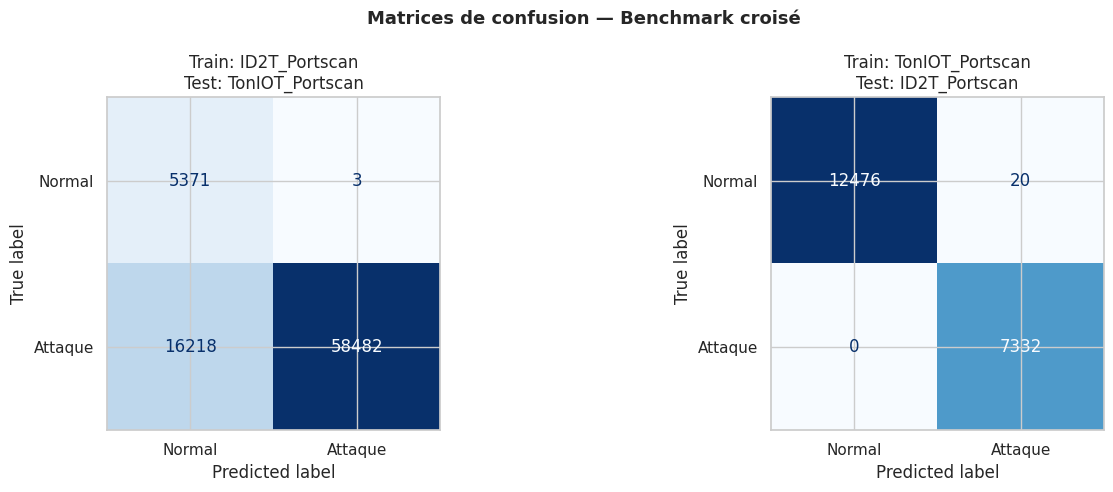

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp in zip(axes, [exp_A_to_B, exp_B_to_A]):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=exp["cm"],
        display_labels=["Normal", "Attaque"]
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Train: {exp['train_name']}\nTest: {exp['test_name']}")

plt.suptitle('Matrices de confusion — Benchmark croisé', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

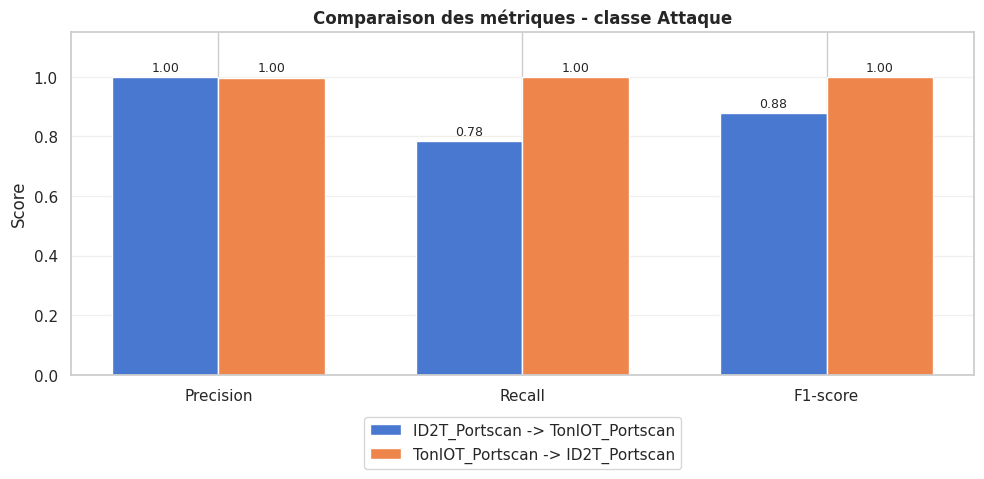

In [ ]:
metrics_data = {
    f"{exp_A_to_B['train_name']} -> {exp_A_to_B['test_name']}": exp_A_to_B["report"]["Attaque"],
    f"{exp_B_to_A['train_name']} -> {exp_B_to_A['test_name']}": exp_B_to_A["report"]["Attaque"],
}

metrics_names = ["precision", "recall", "f1-score"]
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('muted', 2)

for i, (exp_label, metrics) in enumerate(metrics_data.items()):
    values = [metrics[m] for m in metrics_names]
    bars = ax.bar(x + i*width - width/2, values, width, label=exp_label, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-score'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparaison des métriques - classe Attaque', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ Résumé final

In [ ]:
def print_summary(exp):
    r = exp["report"]["Attaque"]
    fn = exp["cm"][1, 0]
    fp = exp["cm"][0, 1]
    print(f"  Train: {exp['train_name']:<25} Test: {exp['test_name']:<25}")
    print(f"    Precision : {r['precision']*100:.2f}%")
    print(f"    Recall    : {r['recall']*100:.2f}%")
    print(f"    F1-score  : {r['f1-score']*100:.2f}%")
    print(f"    Faux négatifs (attaques ratées) : {fn:,}")
    print(f"    Faux positifs (fausses alertes) : {fp:,}")
    print()

print("╔══════════════════════════════════════════════════════════╗")
print("║         RÉSUMÉ — BENCHMARK CROSS-DATASET                ║")
print("╠══════════════════════════════════════════════════════════╣")
print()
print_summary(exp_A_to_B)
print_summary(exp_B_to_A)
print("╠══════════════════════════════════════════════════════════╣")
print("║  Interprétation :                                        ║")
print("║  Un fort écart de recall entre les deux sens indique     ║")
print("║  que les signatures d'attaque diffèrent significativement║")
print("║  entre les deux environnements/datasets.                 ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║         RÉSUMÉ — BENCHMARK CROSS-DATASET                ║
╠══════════════════════════════════════════════════════════╣

  Train: ID2T_Portscan             Test: TonIOT_Portscan          
    Precision : 99.99%
    Recall    : 78.29%
    F1-score  : 87.82%
    Faux négatifs (attaques ratées) : 16,218
    Faux positifs (fausses alertes) : 3

  Train: TonIOT_Portscan           Test: ID2T_Portscan            
    Precision : 99.73%
    Recall    : 100.00%
    F1-score  : 99.86%
    Faux négatifs (attaques ratées) : 0
    Faux positifs (fausses alertes) : 20

╠══════════════════════════════════════════════════════════╣
║  Interprétation :                                        ║
║  Un fort écart de recall entre les deux sens indique     ║
║  que les signatures d'attaque diffèrent significativement║
║  entre les deux environnements/datasets.                 ║
╚══════════════════════════════════════════════════════════╝


In [ ]:
summary_rows = []
for exp in [exp_A_to_B, exp_B_to_A]:
    r = exp["report"]["Attaque"]
    summary_rows.append({
        "train_dataset": exp["train_name"],
        "test_dataset" : exp["test_name"],
        "n_train"      : exp["n_train"],
        "n_test"       : exp["n_test"],
        "precision"    : r["precision"],
        "recall"       : r["recall"],
        "f1_score"     : r["f1-score"],
        "false_negatives": exp["cm"][1, 0],
        "false_positives": exp["cm"][0, 1],
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = f"{SAVE_DIR}benchmark_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"✅ Résumé exporté : {summary_path}")
summary_df

✅ Résumé exporté : /content/benchmark_summary.csv


,train_dataset,test_dataset,n_train,n_test,precision,recall,f1_score,false_negatives,false_positives
0,ID2T_Portscan,TonIOT_Portscan,19828,80074,0.999949,0.782892,0.878207,16218,3
1,TonIOT_Portscan,ID2T_Portscan,80074,19828,0.997280,1.000000,0.998638,0,20


In [ ]:
files.download(summary_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Comparaison datasets
On observe ici les flux réseaux grâce à t-SNE. L'objectif est de voir si les attaques générées artificiellement sont proches des attaques présentes initialement dans le dataset.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# import the generated dataset (gen_dataset) and the original one (lab_dataset)
#GEN_DATASET_PATH = "/content/drive/MyDrive/PHD/Ressources/ID2T_Portscan_clean.csv"
#LAB_DATASET_PATH = "/content/drive/MyDrive/PHD/Ressources/CICIDS2017_Friday_Portscan_clean.csv"
GEN_DATASET_PATH = "/content/ID2T_Portscan_clean.csv"
LAB_DATASET_PATH = "/content/TonIOT_Portscan_clean.csv"

gen_dataset_df = pd.read_csv(GEN_DATASET_PATH)
lab_dataset_df = pd.read_csv(LAB_DATASET_PATH)

# labels from the generated dataset begin with "g.." for better viz
gen_labels = list( map(
    lambda x: f"g_{x}",
    gen_dataset_df["label_binary"].to_numpy())
  )
lab_labels = lab_dataset_df["label_binary"].to_numpy()
labels = np.concatenate([gen_labels, lab_labels])

gen_dataset = gen_dataset_df.drop(columns=["label_binary"]).to_numpy()
lab_dataset = lab_dataset_df.drop(columns=["label_binary"]).to_numpy()
dataset = np.concatenate([gen_dataset, lab_dataset], axis=0)

# idx selection
#idx = np.where(np.char.find(labels, '1') != -1)[0] # normal only
idx = np.where(np.char.find(labels, '0') != -1)[0] # attack only
#idx = np.arange(len(dataset)) # both

# undersampling for viz
sample_size = 40000
idx_sample = np.random.choice([i for i,_ in enumerate(dataset)], size=min(sample_size, len(dataset)), replace=False)

# apply t-SNE
dataset_embeded = TSNE(n_components=2,
                       learning_rate="auto").fit_transform(dataset[idx_sample, :])
labels_embeded = labels[idx_sample]



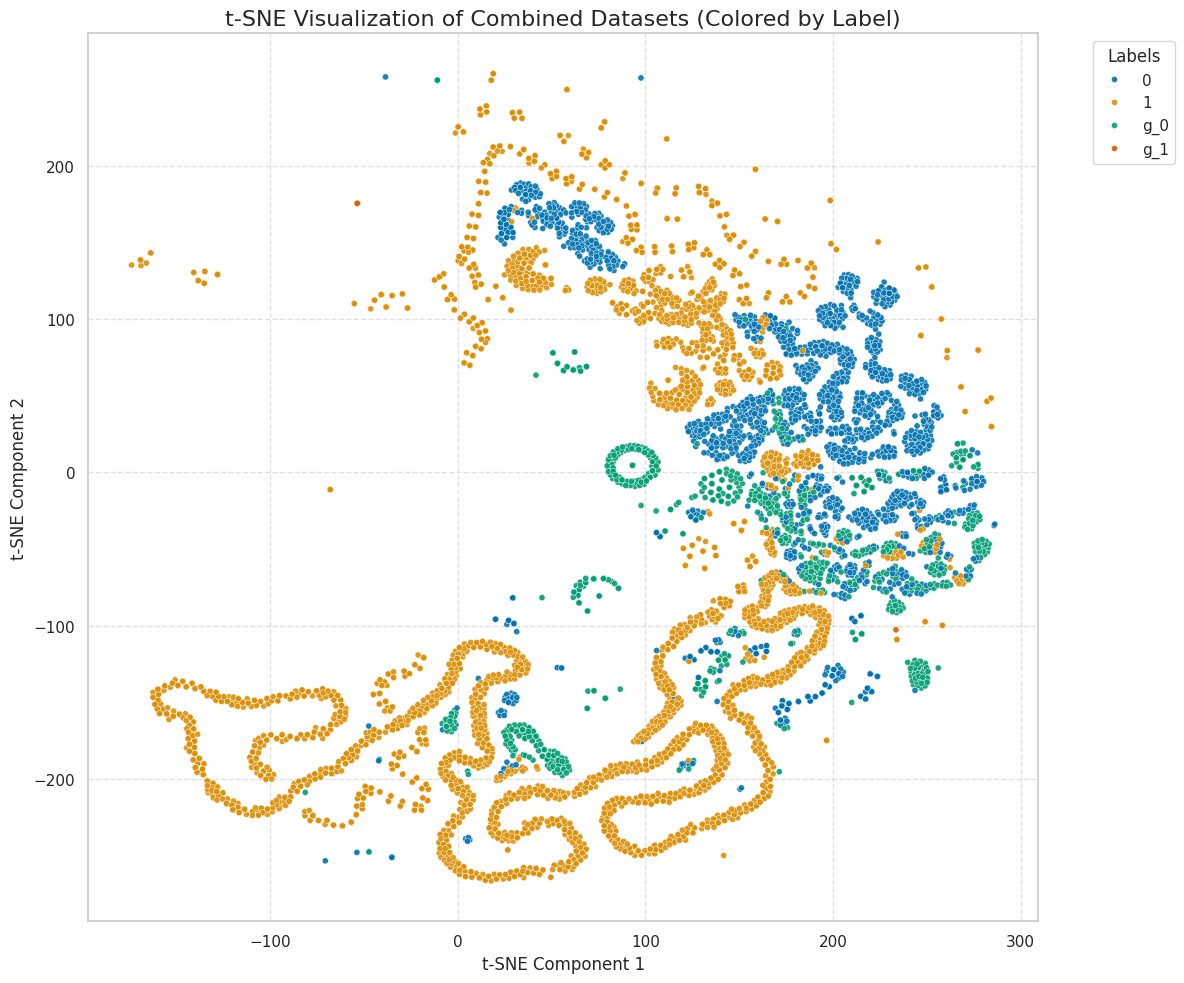

In [ ]:

# Create a scatter plot of the t-SNE embedded data
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=dataset_embeded[:, 0],
    y=dataset_embeded[:, 1],
    hue=labels_embeded,
    palette='colorblind',
    s=20, alpha=0.9
)
plt.title('t-SNE Visualization of Combined Datasets (Colored by Label)', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate t-SNE embedding (this was commented out previously)
dataset_embeded = TSNE(n_components=2, learning_rate="auto", init="random").fit_transform(dataset)

KeyboardInterrupt: 

# **Comparaison des datasets avec PCA**

On observe ici les flux réseau grâce à la PCA. L'objectif est de vérifier si les attaques générées artificiellement occupent la même distribution globale que les attaques du dataset original, en projetant les données sur les deux composantes principales expliquant la plus grande partie de la variance.

# Pour les flux normaux :

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# import
GEN_DATASET_PATH = "/content/ID2T_Portscan_clean.csv"
LAB_DATASET_PATH = "/content/TonIOT_Portscan_clean.csv"

gen_dataset_df = pd.read_csv(GEN_DATASET_PATH)
lab_dataset_df = pd.read_csv(LAB_DATASET_PATH)

# labels
gen_labels = np.array([f"g_{x}" for x in gen_dataset_df["label_binary"]])
lab_labels = lab_dataset_df["label_binary"].astype(str).to_numpy()

labels = np.concatenate([gen_labels, lab_labels])

gen_dataset = gen_dataset_df.drop(columns=["label_binary"]).to_numpy()
lab_dataset = lab_dataset_df.drop(columns=["label_binary"]).to_numpy()

dataset = np.concatenate([gen_dataset, lab_dataset], axis=0)

# Select only normal (0) or attack (1)
idx = np.where(np.char.find(labels.astype(str), '0') != -1)[0] #benin
# idx = np.where(np.char.find(labels.astype(str), '1') != -1)[0] #attaque
# idx = np.arange(len(dataset))

# Undersampling for visualization
sample_size = 100000
idx_sample = np.random.choice(
    idx,
    size=min(sample_size, len(idx)),
    replace=False
)

X = dataset[idx_sample]
y = labels[idx_sample]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
dataset_embedded = pca.fit_transform(X_scaled)

print(f"Variance expliquée PC1 : {pca.explained_variance_ratio_[0]:.3f}")
print(f"Variance expliquée PC2 : {pca.explained_variance_ratio_[1]:.3f}")
print(f"Variance totale : {pca.explained_variance_ratio_.sum():.3f}")



Variance expliquée PC1 : 0.203
Variance expliquée PC2 : 0.107
Variance totale : 0.311


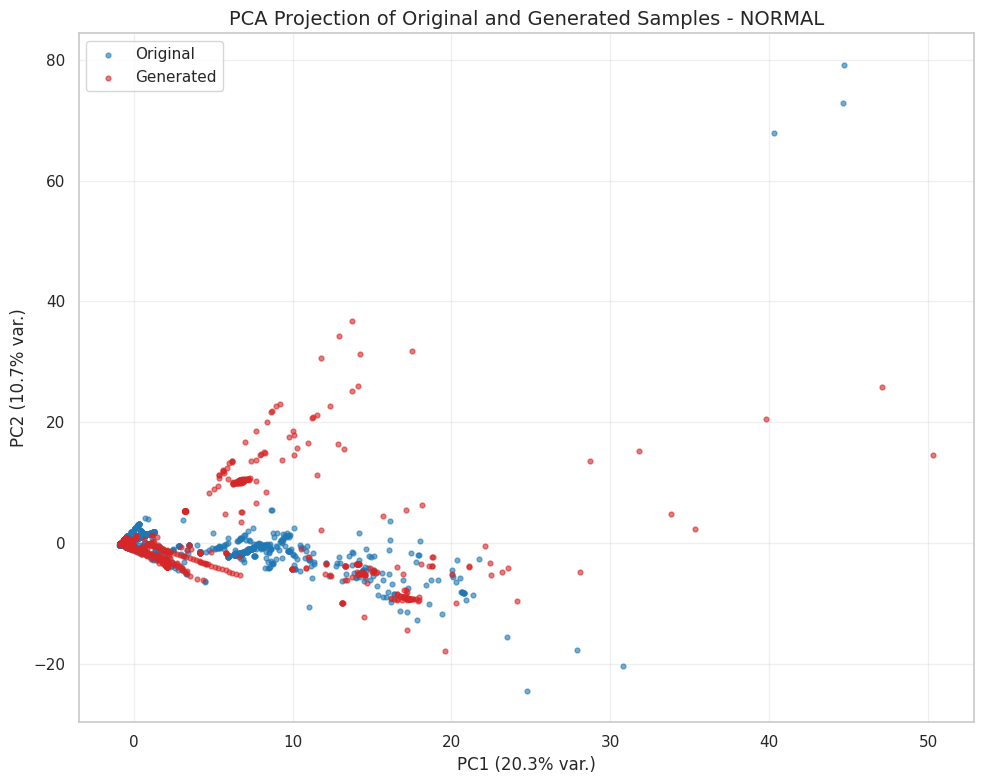

In [ ]:
# ==========================
# Plot PCA benin/normal
# ==========================

plt.figure(figsize=(10, 8))

# Original dataset
mask_real = np.array([not lbl.startswith("g_") for lbl in y])
plt.scatter(
    dataset_embedded[mask_real, 0],
    dataset_embedded[mask_real, 1],
    s=12,
    alpha=0.6,
    c="tab:blue",
    label="Original"
)

# Generated dataset
mask_gen = np.array([lbl.startswith("g_") for lbl in y])
plt.scatter(
    dataset_embedded[mask_gen, 0],
    dataset_embedded[mask_gen, 1],
    s=12,
    alpha=0.6,
    c="tab:red",
    label="Generated"
)

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var.)",
    fontsize=12
)
plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var.)",
    fontsize=12
)
plt.title("PCA Projection of Original and Generated Samples - NORMAL", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Pour les flux d'attaque :

In [ ]:
# Select only normal (0) or attack (1)
idx = np.where(np.char.find(labels.astype(str), '1') != -1)[0] #attaque


# Undersampling for visualization
sample_size = 100000
idx_sample = np.random.choice(
    idx,
    size=min(sample_size, len(idx)),
    replace=False
)

X = dataset[idx_sample]
y = labels[idx_sample]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
dataset_embedded = pca.fit_transform(X_scaled)

print(f"Variance expliquée PC1 : {pca.explained_variance_ratio_[0]:.3f}")
print(f"Variance expliquée PC2 : {pca.explained_variance_ratio_[1]:.3f}")
print(f"Variance totale : {pca.explained_variance_ratio_.sum():.3f}")


Variance expliquée PC1 : 0.353
Variance expliquée PC2 : 0.165
Variance totale : 0.517


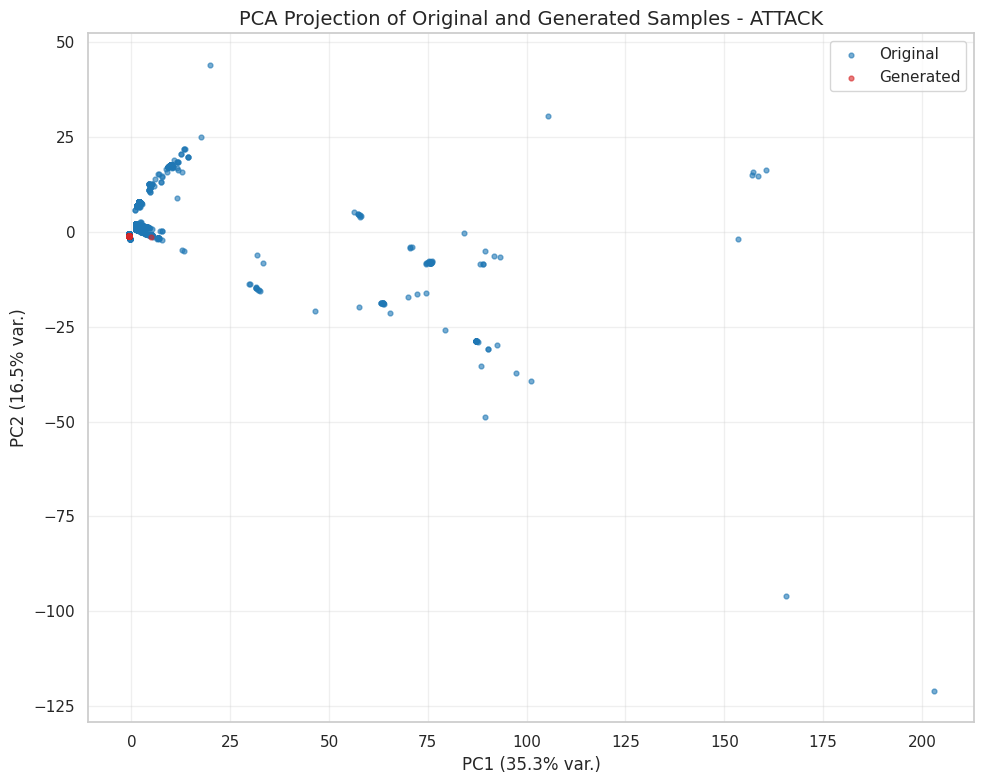

In [ ]:
# ==========================
# Plot PCA Attack
# ==========================

plt.figure(figsize=(10, 8))

# Original dataset
mask_real = np.array([not lbl.startswith("g_") for lbl in y])
plt.scatter(
    dataset_embedded[mask_real, 0],
    dataset_embedded[mask_real, 1],
    s=12,
    alpha=0.6,
    c="tab:blue",
    label="Original"
)

# Generated dataset
mask_gen = np.array([lbl.startswith("g_") for lbl in y])
plt.scatter(
    dataset_embedded[mask_gen, 0],
    dataset_embedded[mask_gen, 1],
    s=12,
    alpha=0.6,
    c="tab:red",
    label="Generated"
)

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var.)",
    fontsize=12
)
plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var.)",
    fontsize=12
)
plt.title("PCA Projection of Original and Generated Samples - ATTACK", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()